variable   : pr
time index : -1
zoom       : 6
store      : /scratch/k/k202181/remap_eerie/eerie-hist-1950-v20240618/eerie-hist-1950-v20240618_P1M_mean_6.zarr

SOURCE -> min=3.323421191e-19, max=0.002149213105, mean=3.806174759e-05
ZARR   -> min=1.938260778e-18, max=0.0004884317168, mean=3.826515312e-05

TIME CHECK
source time dtype      : datetime64[ns]
dest   time dtype      : datetime64[ns]
source time[-1] : 2014-12-31T23:59:59.000000000
dest   time[-1] : 2014-12-31T23:59:59.000000000
time axis same length  : True
time axis exact match  : True

dest plot mode: actual HEALPix polygons (49152 cells)


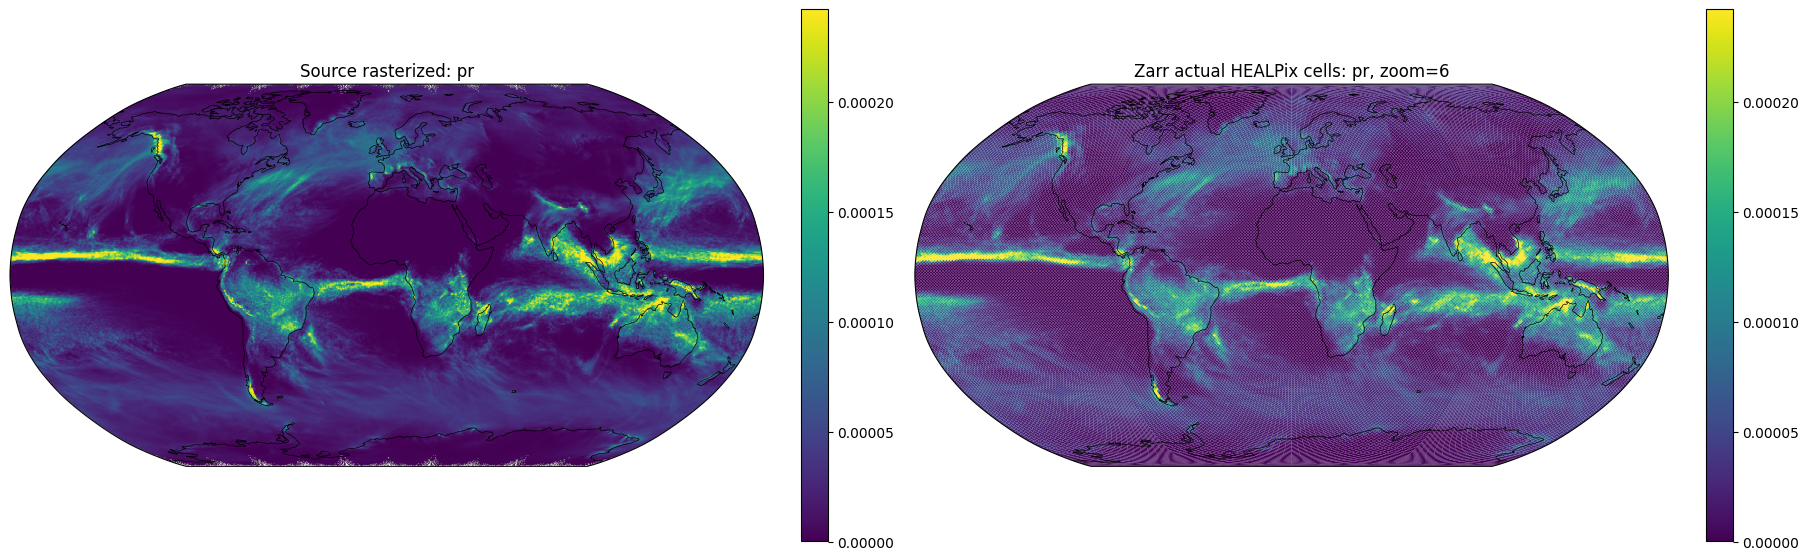

In [12]:
import numpy as np
import xarray as xr
import uxarray as ux
import requests
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.collections import PolyCollection

import cartopy.crs as ccrs

# ============================================================
# settings
# ============================================================
VAR_NAME = "pr"          # "ts" or "pr"
TIME_INDEX = -1
ZOOM = 6                 # 4/5/6 good for actual HEALPix polygons; high zoom falls back
NX = 720
NY = 360
MAX_DEST_POLYGONS = 200_000

DATASET_ID = "eerie-hist-1950-v20240618"
FREQUENCY_TAG = "P1M"
STAT_TAG = "mean"

STAC_ITEM_URL = (
    "https://stac2.cloud.dkrz.de/fastapi/collections/"
    "eerie-eerie-mpi-m-icon-esm-er-hist-1950-v20240618/items/"
    "eerie-eerie-mpi-m-icon-esm-er-hist-1950-v20240618-"
    "disk.model-output.icon-esm-er.hist-1950.v20240618.atmos.native.2d_monthly_mean-zarr-kerchunk"
)
ASSET = "dkrz-disk"

GRIDFILE = "/pool/data/ICON/grids/public/mpim/0033/icon_grid_0033_R02B08_G.nc"
OUT_ROOT = "/scratch/k/k202181/remap_eerie/eerie-hist-1950-v20240618"

# ============================================================
# helpers
# ============================================================
def to_deg(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if np.nanmax(np.abs(arr)) <= np.pi + 0.01:
        return np.rad2deg(arr)
    return arr

def nanstats(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return {
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
        "mean": float(np.nanmean(arr)),
    }

def decode_time_like(da: xr.DataArray):
    vals = np.asarray(da.values)
    if np.issubdtype(vals.dtype, np.datetime64):
        return vals.astype("datetime64[ns]")
    try:
        tmp = xr.decode_cf(xr.Dataset(coords={"time": da}))
        vals2 = np.asarray(tmp["time"].values)
        if np.issubdtype(vals2.dtype, np.datetime64):
            return vals2.astype("datetime64[ns]")
        return vals2
    except Exception:
        return vals

def rasterize_face_centers(lon_deg, lat_deg, values, nx=720, ny=360):
    lon = ((np.asarray(lon_deg, dtype=np.float64) + 180.0) % 360.0) - 180.0
    lat = np.clip(np.asarray(lat_deg, dtype=np.float64), -90.0, 90.0)
    val = np.asarray(values, dtype=np.float64)

    good = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val)
    lon = lon[good]
    lat = lat[good]
    val = val[good]

    ix = np.floor((lon + 180.0) / 360.0 * nx).astype(np.int64)
    iy = np.floor((lat + 90.0) / 180.0 * ny).astype(np.int64)

    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)

    flat = iy * nx + ix
    sums = np.bincount(flat, weights=val, minlength=nx * ny)
    counts = np.bincount(flat, minlength=nx * ny)

    out = np.full(nx * ny, np.nan, dtype=np.float64)
    m = counts > 0
    out[m] = sums[m] / counts[m]
    return out.reshape(ny, nx)

def build_face_polygons(grid, values):
    """
    Build actual cell polygons for a UXarray grid.
    Longitudes are adjusted around each face center to avoid dateline-spanning artifacts.
    """
    node_lon = to_deg(grid.node_lon.values)
    node_lat = to_deg(grid.node_lat.values)
    face_lon = to_deg(grid.face_lon.values)

    conn = np.asarray(grid.face_node_connectivity.values)
    n_nodes_per_face = np.asarray(grid.n_nodes_per_face.values, dtype=np.int64)
    vals = np.asarray(values, dtype=np.float64)

    polys = []
    poly_vals = []

    n_face = int(n_nodes_per_face.size)
    for i in range(n_face):
        if not np.isfinite(vals[i]):
            continue

        m = int(n_nodes_per_face[i])
        ids = np.asarray(conn[i, :m], dtype=np.int64)
        ids = ids[ids >= 0]

        if ids.size < 3:
            continue

        lons = node_lon[ids].astype(np.float64)
        lats = node_lat[ids].astype(np.float64)
        clon = float(face_lon[i])

        # adjust node longitudes to stay close to face center
        lons = ((lons - clon + 180.0) % 360.0) - 180.0 + clon

        polys.append(np.column_stack([lons, lats]))
        poly_vals.append(vals[i])

    return polys, np.asarray(poly_vals, dtype=np.float64)

# ============================================================
# open source dataset
# ============================================================
resp = requests.get(STAC_ITEM_URL)
resp.raise_for_status()
item = resp.json()

source_ds = xr.open_dataset(
    item["assets"][ASSET]["href"],
    **item["assets"][ASSET]["xarray:open_kwargs"],
    storage_options=item["assets"][ASSET].get("xarray:storage_options"),
)

# ============================================================
# open source grid + source field
# ============================================================
src_grid = ux.open_grid(GRIDFILE, chunks=-1)

src_da = source_ds[VAR_NAME].isel(time=TIME_INDEX).squeeze(drop=True).compute()
src_vals = np.asarray(src_da.values)
src_lon = to_deg(src_grid.face_lon.values)
src_lat = to_deg(src_grid.face_lat.values)

# ============================================================
# open written zarr result
# ============================================================
store_path = str(Path(OUT_ROOT) / f"{DATASET_ID}_{FREQUENCY_TAG}_{STAT_TAG}_{ZOOM}.zarr")
dst_ds = xr.open_zarr(store_path, consolidated=False)

dst_da = dst_ds[VAR_NAME].isel(time=TIME_INDEX).squeeze(drop=True)
dst_vals = np.asarray(dst_da.values)

dst_grid = ux.Grid.from_healpix(zoom=ZOOM, pixels_only=False, nest=True)
dst_lon = to_deg(dst_grid.face_lon.values)
dst_lat = to_deg(dst_grid.face_lat.values)

# ============================================================
# stats
# ============================================================
src_stats = nanstats(src_vals)
dst_stats = nanstats(dst_vals)

print(f"variable   : {VAR_NAME}")
print(f"time index : {TIME_INDEX}")
print(f"zoom       : {ZOOM}")
print(f"store      : {store_path}")
print()
print(
    f"SOURCE -> min={src_stats['min']:.10g}, max={src_stats['max']:.10g}, mean={src_stats['mean']:.10g}"
)
print(
    f"ZARR   -> min={dst_stats['min']:.10g}, max={dst_stats['max']:.10g}, mean={dst_stats['mean']:.10g}"
)
print()

# ============================================================
# time check
# ============================================================
src_time_all = decode_time_like(source_ds["time"])
dst_time_all = decode_time_like(dst_ds["time"])

src_time_i = src_time_all[TIME_INDEX]
dst_time_i = dst_time_all[TIME_INDEX]

same_len = len(src_time_all) == len(dst_time_all)
same_values = same_len and np.array_equal(src_time_all, dst_time_all)

print("TIME CHECK")
print(f"source time dtype      : {source_ds['time'].dtype}")
print(f"dest   time dtype      : {dst_ds['time'].dtype}")
print(f"source time[{TIME_INDEX}] : {src_time_i}")
print(f"dest   time[{TIME_INDEX}] : {dst_time_i}")
print(f"time axis same length  : {same_len}")
print(f"time axis exact match  : {same_values}")

if not same_values and same_len:
    diff_idx = np.flatnonzero(src_time_all != dst_time_all)
    if diff_idx.size > 0:
        j = int(diff_idx[0])
        print(f"first differing time index: {j}")
        print(f"  source[{j}] = {src_time_all[j]}")
        print(f"  dest  [{j}] = {dst_time_all[j]}")
print()

# ============================================================
# common color scale
# ============================================================
finite_src = src_vals[np.isfinite(src_vals)]
finite_dst = dst_vals[np.isfinite(dst_vals)]
all_vals = np.concatenate([finite_src, finite_dst])

vmin = np.nanpercentile(all_vals, 1)
vmax = np.nanpercentile(all_vals, 99)
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin = np.nanmin(all_vals)
    vmax = np.nanmax(all_vals)

# ============================================================
# plotting
# left  : rasterized source (source mesh too large for polygon plotting)
# right : actual HEALPix cell polygons for small zooms, otherwise raster fallback
# ============================================================
fig = plt.figure(figsize=(18, 6), constrained_layout=True)
proj = ccrs.Robinson()

ax1 = fig.add_subplot(1, 2, 1, projection=proj)
ax2 = fig.add_subplot(1, 2, 2, projection=proj)

# source raster
src_img = rasterize_face_centers(src_lon, src_lat, src_vals, nx=NX, ny=NY)
im1 = ax1.imshow(
    src_img,
    origin="lower",
    extent=(-180, 180, -90, 90),
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
)
ax1.coastlines(linewidth=0.5)
ax1.set_global()
ax1.set_title(f"Source rasterized: {VAR_NAME}")

# destination actual polygons if feasible
n_dst_face = int(dst_grid.n_face)
if n_dst_face <= MAX_DEST_POLYGONS:
    polys, poly_vals = build_face_polygons(dst_grid, dst_vals)
    coll = PolyCollection(
        polys,
        array=poly_vals,
        edgecolors="none",
        closed=True,
        transform=ccrs.PlateCarree(),
    )
    coll.set_clim(vmin, vmax)
    ax2.add_collection(coll)
    ax2.coastlines(linewidth=0.5)
    ax2.set_global()
    ax2.set_title(f"Zarr actual HEALPix cells: {VAR_NAME}, zoom={ZOOM}")
    plt.colorbar(coll, ax=ax2, shrink=0.9)
    print(f"dest plot mode: actual HEALPix polygons ({n_dst_face} cells)")
else:
    dst_img = rasterize_face_centers(dst_lon, dst_lat, dst_vals, nx=NX, ny=NY)
    im2 = ax2.imshow(
        dst_img,
        origin="lower",
        extent=(-180, 180, -90, 90),
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax2.coastlines(linewidth=0.5)
    ax2.set_global()
    ax2.set_title(f"Zarr rasterized fallback: {VAR_NAME}, zoom={ZOOM}")
    plt.colorbar(im2, ax=ax2, shrink=0.9)
    print(f"dest plot mode: raster fallback ({n_dst_face} cells > {MAX_DEST_POLYGONS})")

plt.colorbar(im1, ax=ax1, shrink=0.9)
plt.show()